## Data subset and baseline configuration.

In [1]:
!wget https://raw.githubusercontent.com/allenai/bi-att-flow/master/squad/evaluate-v1.1.py -O evaluate_v1.py
!pip install rank_bm25 -q


--2026-05-24 11:16:08--  https://raw.githubusercontent.com/allenai/bi-att-flow/master/squad/evaluate-v1.1.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3419 (3.3K) [text/plain]
Saving to: ‘evaluate_v1.py’

evaluate_v1.py      100%[===================>]   3.34K  --.-KB/s    in 0s      

2026-05-24 11:16:08 (43.1 MB/s) - ‘evaluate_v1.py’ saved [3419/3419]



In [1]:
!pip uninstall -y torch torchvision torchaudio transformers

Found existing installation: torch 2.12.0+cpu
Uninstalling torch-2.12.0+cpu:
  Successfully uninstalled torch-2.12.0+cpu
Found existing installation: torchvision 0.27.0+cpu
Uninstalling torchvision-0.27.0+cpu:
  Successfully uninstalled torchvision-0.27.0+cpu
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu
Found existing installation: transformers 5.9.0
Uninstalling transformers-5.9.0:
  Successfully uninstalled transformers-5.9.0


In [4]:
#cpu
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
#!pip install transformers datasets accelerate evaluate

In [2]:
# GPU PyTorch (CUDA 12.1)
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Stable NLP stack (compatible with QA)
#pip install transformers==4.41.0 datasets==2.19.0 accelerate==0.30.1 evaluate

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 98.6 MB/s  0:00:03:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 230.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 195.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 236.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 114.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 230.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 156.9 MB/s  0:00:0200:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 182.7 MB/s  0:00:0100:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 194.2 MB/s  0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 261.2 MB/s  0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 261.4 MB/s  0:00:0000:0100:01
     ━━

In [ ]:
#pip install --upgrade datasets accelerate evaluate

In [1]:
import torch
import transformers

print(torch.__version__)
print(transformers.__version__)

2.5.1+cu121
4.41.0


In [ ]:
import json
import urllib.request
import os
import re
from transformers import DistilBertTokenizerFast
from evaluate_v1 import normalize_answer, exact_match_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from rank_bm25 import BM25Okapi

os.environ["HF_TOKEN"] = ""
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Global preprocessing storage
all_encodings = []
articles = []
train_articles = []
train_encoding_strided, train_input_ids, train_attention_masks, train_start_positions, train_end_positions = [], [], [], [], []
val_articles = []
val_encoding_strided, val_input_ids, val_attention_masks, val_start_positions, val_end_positions = [], [], [], [], []
test_articles = []
test_encoding_strided, test_input_ids, test_attention_masks, test_start_positions, test_end_positions = [], [], [], [], []

## Pre-processing Steps Include:
1.   Load SQuAD and inspect the JSON structure.
2.   Clean only lightly, not aggressively.
3.   Tokenize question and context together with special tokens.
4.   Use truncation and a stride/window approach.
5.   Compute answer start and end offsets.
6.   Create train/validation/test splits.

**Load SQuAD and inspect the JSON structure.**


*   Download Squad V2.0 both training and evaluation data.
*   List keys and investigate first 5 items.
*   Check that every ``answer_start`` offset in the dataset actually points to the correct position in the context string. (Sanity Check)




In [2]:
URLS = {
    "train_v1": "https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v1.1.json"
}

for name, url in URLS.items():
    filename = url.split("/")[-1]
    if not os.path.exists(filename):
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"{filename} already exists, skipping download.")

with open("train-v1.1.json", "r", encoding="utf-8") as f:
    train_v1 = json.load(f)

print(f"SQuAD v1.1 - train articles: {len(train_v1['data'])}")

train-v1.1.json already exists, skipping download.
SQuAD v1.1 - train articles: 442


In [3]:
def print_keys(obj, indent=0):
    prefix = "  " * indent
    if isinstance(obj, dict):
        for key, value in obj.items():
            print(f"{prefix}- {key}")
            print_keys(value, indent + 1)
    elif isinstance(obj, list) and len(obj) > 0:
        print_keys(obj[0], indent + 1)

print("=== SQuAD v1.1 JSON Structure ===")
print_keys(train_v1)

=== SQuAD v1.1 JSON Structure ===
- data
    - title
    - paragraphs
        - context
        - qas
            - answers
                - answer_start
                - text
            - question
            - id
- version


In [4]:
count = 0
for article in train_v1["data"]:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            print(json.dumps({
                "title": article["title"],
                "context": para["context"][:150] + "...",
                "question": qa["question"],
                "answer_text": qa["answers"][0]["text"],
                "answer_start": qa["answers"][0]["answer_start"]
            }, indent=2))
            print("-" * 60)
            count += 1
            if count == 5:
                break
        if count == 5:
            break
    if count == 5:
        break

{
  "title": "University_of_Notre_Dame",
  "context": "Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...",
  "question": "To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?",
  "answer_text": "Saint Bernadette Soubirous",
  "answer_start": 515
}
------------------------------------------------------------
{
  "title": "University_of_Notre_Dame",
  "context": "Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...",
  "question": "What is in front of the Notre Dame Main Building?",
  "answer_text": "a copper statue of Christ",
  "answer_start": 188
}
------------------------------------------------------------
{
  "title": "University_of_Notre_Dame",
  "context": "Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden sta

In [5]:
total = 0
mismatches = []
for article in train_v1["data"]:
    for para in article["paragraphs"]:
        ctx = para["context"]
        for qa in para["qas"]:
            for ans in qa["answers"]:
                total += 1
                start = ans["answer_start"]
                end = start + len(ans["text"])
                extracted = ctx[start:end]
                if extracted != ans["text"]:
                    mismatches.append({
                        "id": qa["id"],
                        "expected": ans["text"],
                        "got": extracted
                    })

print(f"Checked  : {total} answer spans")
print(f"Mismatches: {len(mismatches)}")

if mismatches:
    print("\nFirst 3 mismatches:")
    for m in mismatches[:3]:
        print(f"  id={m['id']}  expected='{m['expected']}'  got='{m['got']}'")
else:
    print("All spans aligned correctly.")

Checked  : 87599 answer spans
Mismatches: 0
All spans aligned correctly.


**Clean only lightly, not aggressively.**


*    Collapse multiple spaces into one and strips leading/trailing whitespace.
*    Remove unanswerable questions, where ``is_impossible`` field distinguishes v2.0 from v1.1, it flags questions that have no answer in the context.

In [6]:
def clean_dataset(dataset):
    for article in train_v1["data"]:
      for para in article["paragraphs"]:
          para["context"] = re.sub(r" +", " ", para["context"]).strip()
          for qa in para["qas"]:
              qa["question"] = re.sub(r" +", " ", qa["question"]).strip()

    return dataset

In [7]:
train_v1 = clean_dataset(train_v1)

**Tokenize question and context together with special tokens.**
*   CPU time grows fast with sequence length, and a stride/window lets you keep contexts smaller while still preserving answers near boundaries.

In [8]:
def tokenize(sample_question, sample_context):
  document_stride = 128
  encoding_strided = tokenizer(
      sample_question,
      sample_context,
      truncation="only_second",
      max_length=512,
      stride=document_stride,
      return_overflowing_tokens=True,
      padding="max_length",
      return_offsets_mapping=True,
      return_tensors="pt"
  )
  return encoding_strided



In [9]:

sample_question = train_v1["data"][0]["paragraphs"][0]["qas"][0]["question"]
sample_context  = train_v1["data"][0]["paragraphs"][0]["context"]
encoding_strided = tokenize(sample_question, sample_context)

print(f"Number of chunks produced : {encoding_strided['input_ids'].shape[0]}")
print(f"Each chunk shape          : {encoding_strided['input_ids'].shape[1:]}")

for i in range(encoding_strided['input_ids'].shape[0]):
    tokens = encoding_strided['input_ids'][i].tolist()
    mask = encoding_strided['attention_mask'][i].tolist()
    real_tokens = mask.count(1)
    pad_tokens = mask.count(0)
    print(f"\nChunk {i+1}:")
    print(f"  Real tokens : {real_tokens}")
    print(f"  PAD tokens  : {pad_tokens}")
    print(f"  First 10 decoded: {tokenizer.convert_ids_to_tokens(tokens[:10])}")
    print(f"  Last  10 decoded: {tokenizer.convert_ids_to_tokens(tokens[-10:])}")

Number of chunks produced : 1
Each chunk shape          : torch.Size([512])

Chunk 1:
  Real tokens : 176
  PAD tokens  : 336
  First 10 decoded: ['[CLS]', 'to', 'whom', 'did', 'the', 'virgin', 'mary', 'allegedly', 'appear', 'in']
  Last  10 decoded: ['[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


**Compute answer start and end offsets**

In [10]:
def offset_mapping(answer, encoding_strided):
    ans_start = answer["answer_start"]
    ans_end   = ans_start + len(answer["text"])

    results = []

    for i in range(encoding_strided['input_ids'].shape[0]):
        offsets = encoding_strided['offset_mapping'][i].tolist()
        sequence_ids = encoding_strided.sequence_ids(i)  # tells us which tokens belong to the question (0) and which to the context (1)

        # Find where the context tokens start and end in this chunk
        ctx_start = next(j for j, s in enumerate(sequence_ids) if s == 1)
        ctx_end = len(sequence_ids) - 1 - next(j for j, s in enumerate(reversed(sequence_ids)) if s == 1)

        # Check if the answer is even inside this chunk
        if offsets[ctx_start][0] > ans_start or offsets[ctx_end][1] < ans_end:
            start_pos, end_pos = 0, 0
        else:
            # Walk tokens to find which one contains ans_start and ans_end
            start_pos = next((j for j in range(ctx_start, ctx_end+1) if offsets[j][0] <= ans_start < offsets[j][1]), ctx_start)
            end_pos = next((j for j in range(ctx_end, ctx_start-1, -1) if offsets[j][1] >= ans_end > offsets[j][0]), ctx_end)

        results.append((start_pos, end_pos))

    return results

In [11]:
sample_question = train_v1["data"][0]["paragraphs"][0]["qas"][0]["question"]
sample_context = train_v1["data"][0]["paragraphs"][0]["context"]
sample_answer = train_v1["data"][0]["paragraphs"][0]["qas"][0]["answers"][0]
encoding_strided = tokenize(sample_question, sample_context)
chunk_positions  = offset_mapping(sample_answer, encoding_strided)

print(f"Question : {sample_question}")
print(f"Answer   : {sample_answer}")
print(f"Context  : {sample_context[:150]}...")
print(f"Chunks   : {len(chunk_positions)}")

for i, (start_pos, end_pos) in enumerate(chunk_positions):
    print(f"\nChunk {i+1}: start_position={start_pos}, end_position={end_pos}")
    tokens = encoding_strided['input_ids'][i].tolist()
    if start_pos != 0 and end_pos != 0:
        predicted_answer = tokenizer.convert_tokens_to_string(
            tokenizer.convert_ids_to_tokens(tokens[start_pos:end_pos+1])
        )
        print(f"  Recovered answer: '{predicted_answer}'")
    else:
        print(f"  Answer not in this chunk")

Question : To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answer   : {'answer_start': 515, 'text': 'Saint Bernadette Soubirous'}
Context  : Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...
Chunks   : 1

Chunk 1: start_position=130, end_position=137
  Recovered answer: 'saint bernadette soubirous'


*Note: Runnig Time 4-5 minuites*

**Create train/validation/test splits**
*   Split train_v1 into 80/10/10 Splits.
*   Subset Filterin, slice train set down to 50k QA pairs.

In [12]:
import random

# Fix seed for reproducibility
random.seed(42)

# Get all articles and shuffle
articles = train_v1["data"].copy()
random.shuffle(articles)

# Split at article level 80/10/10
total = len(articles)
train_end = int(0.8 * total)
val_end = int(0.9 * total)

train_articles = articles[:train_end]
val_articles = articles[train_end:val_end]
test_articles = articles[val_end:]

print(f"Train articles      : {len(train_articles)}")
print(f"Validation articles : {len(val_articles)}")
print(f"Test articles       : {len(test_articles)}")

Train articles      : 353
Validation articles : 44
Test articles       : 45


In [13]:
subset_articles = []
qa_count = 0

for article in train_articles:
    article_qa = sum(len(para["qas"]) for para in article["paragraphs"])
    if qa_count <= 50000:
        subset_articles.append(article)
        qa_count += article_qa
    if qa_count >= 50000:
        break

train_articles = subset_articles
print(f"Subset articles : {len(train_articles)}")
print(f"Subset QA pairs : {qa_count}")

Subset articles : 245
Subset QA pairs : 50012


In [14]:
for article in train_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                train_encoding_strided.append(encoding_strided)
                train_input_ids.append(encoding_strided['input_ids'][i].tolist())
                train_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                train_start_positions.append(start_pos)
                train_end_positions.append(end_pos)

In [15]:
for article in val_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions  = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                val_encoding_strided.append(encoding_strided)
                val_input_ids.append(encoding_strided['input_ids'][i].tolist())
                val_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                val_start_positions.append(start_pos)
                val_end_positions.append(end_pos)

In [16]:
for article in test_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions  = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                test_encoding_strided.append(encoding_strided)
                test_input_ids.append(encoding_strided['input_ids'][i].tolist())
                test_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                test_start_positions.append(start_pos)
                test_end_positions.append(end_pos)

In [17]:
print(f"Train chunks      : {len(train_input_ids)}")
print(f"Validation chunks : {len(val_input_ids)}")
print(f"Test chunks       : {len(test_input_ids)}")

Train chunks      : 50068
Validation chunks : 9308
Test chunks       : 8078


In [18]:
def count_qa(articles):
    return sum(
        len(para["qas"])
        for article in articles
        for para in article["paragraphs"]
    )

print(f"Train QA pairs      : {count_qa(train_articles)}")
print(f"Validation QA pairs : {count_qa(val_articles)}")
print(f"Test QA pairs       : {count_qa(test_articles)}")

Train QA pairs      : 50012
Validation QA pairs : 9303
Test QA pairs       : 8073


## Computing baseline EM and F1 scores using the official SQuAD evaluation script



In [19]:
baseline_predictions = {}
em_scores = []
f1_scores = []

for article in val_articles:
    for para in article["paragraphs"]:
        context  = para["context"]
        for qa in para["qas"]:
            question = qa["question"]
            gold_answers = [a["text"] for a in qa["answers"]]

            sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', context) if s.strip()]
            if len(sentences) == 0:
                prediction = ""
            elif len(sentences) == 1:
                prediction = sentences[0]
            else:
                tokenized_sentences = [s.lower().split() for s in sentences]
                tokenized_question  = question.lower().split()
                bm25 = BM25Okapi(tokenized_sentences)
                scores = bm25.get_scores(tokenized_question)
                prediction = sentences[np.argmax(scores)]

            baseline_predictions[qa["id"]] = prediction
            em_scores.append(max(exact_match_score(a, prediction) for a in gold_answers))
            f1_scores.append(max(f1_score(a, prediction) for a in gold_answers))

avg_em = sum(em_scores) / len(em_scores) * 100
avg_f1 = sum(f1_scores) / len(f1_scores) * 100

print(f"BM25 Baseline Results on Validation Set")
print(f"Total examples : {len(em_scores)}")
print(f"Exact Match    : {avg_em:.2f}%")
print(f"F1 Score       : {avg_f1:.2f}%")

BM25 Baseline Results on Validation Set
Total examples : 9303
Exact Match    : 0.12%
F1 Score       : 14.19%


In [20]:
sample_para = val_articles[0]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]
gold        = [a["text"] for a in sample_qa["answers"]]

sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', context) if s.strip()]
tokenized_sentences = [s.lower().split() for s in sentences]
tokenized_question  = question.lower().split()
bm25 = BM25Okapi(tokenized_sentences)
scores = bm25.get_scores(tokenized_question)
prediction = sentences[np.argmax(scores)]

print(f"Question    : {question}")
print(f"Gold answers: {gold}")
print(f"Prediction  : {prediction}")
print(f"EM          : {max(exact_match_score(a, prediction) for a in gold)}")
print(f"F1          : {max(f1_score(a, prediction) for a in gold):.4f}")

Question    : Who founded Philadelphia?
Gold answers: ['William Penn']
Prediction  : In 1682, William Penn founded the city to serve as capital of the Pennsylvania Colony.
EM          : False
F1          : 0.2667


In [21]:
with open("bm25_baseline_predictions.json", "w") as f:
    json.dump(baseline_predictions, f)

# Student B

## 🏗️ 4. Model Architecture — DistilBertForQuestionAnswering

In [ ]:
import os, time, tracemalloc, random, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Hardware ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda")
print(f"Using device: {DEVICE}")

# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_CHECKPOINT  = "distilbert-base-uncased"
MAX_SEQ_LENGTH    = 384
STRIDE            = 128
BATCH_SIZE        = 16
GRAD_ACCUM_STEPS  = 2
NUM_EPOCHS        = 3
LEARNING_RATE     = 2e-5
WEIGHT_DECAY      = 0.01
OUTPUT_DIR        = "./distilbert-squad-output"

print("Configuration loaded ✅")

# load data

In [ ]:
# BUG FIX 1: build HuggingFace Datasets from the lists produced by Student A
#             (val_dataset was never defined; Student B referenced a non-existent variable)
# BUG FIX 2: train_input_ids is a plain list, not a Dataset — cannot call .set_format()
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "input_ids":       train_input_ids,
    "attention_mask":  train_attention_masks,
    "start_positions": train_start_positions,
    "end_positions":   train_end_positions,
})

val_dataset = Dataset.from_dict({
    "input_ids":       val_input_ids,
    "attention_mask":  val_attention_masks,
    "start_positions": val_start_positions,
    "end_positions":   val_end_positions,
})

train_dataset.set_format("torch")
val_dataset.set_format("torch")

print(f"Train dataset : {len(train_dataset):,} chunks")
print(f"Val dataset   : {len(val_dataset):,} chunks")

## 🏗️ 4. Model Architecture — DistilBertForQuestionAnswering

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBertForQuestionAnswering.from_pretrained(MODEL_CHECKPOINT).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model          : {MODEL_CHECKPOINT}")
print(f"Total params   : {total_params/1e6:.1f}M")
print(f"Trainable      : {trainable_params/1e6:.1f}M")
print(f"Layers         : 6 Transformer encoder layers")
print(f"Hidden size    : 768  |  Heads: 12  |  FFN: 3072")
print()
print(model)


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

In [ ]:
#train_dataset = train_dataset.select(range(10000))

## 🏋️ 5. Training + Loss Curves

Starting training...


Epoch,Training Loss,Validation Loss
1,1.439430,1.199463
2,1.142501,1.100571
3,0.973321,1.098213


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete — wall-clock time: 0.31 hours


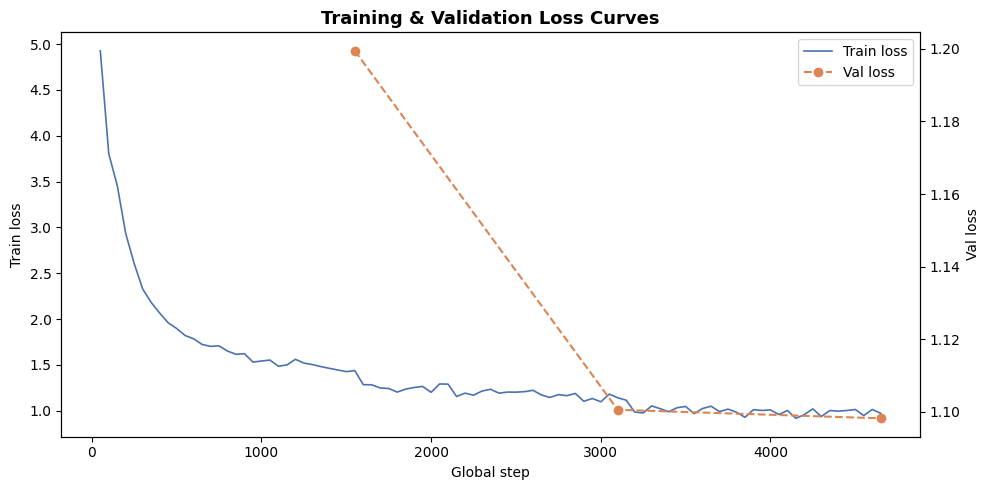

Loss curves saved → loss_curves.png


In [30]:


training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,
    num_train_epochs            = NUM_EPOCHS,
    weight_decay                = WEIGHT_DECAY,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    seed                        = SEED,
    logging_steps               = 50,
    report_to                   = "none",
    fp16=True
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    data_collator = default_data_collator,
)

print("Starting training...")
train_start  = time.time()
train_output = trainer.train()
train_end    = time.time()
wall_clock_hrs = (train_end - train_start) / 3600
print(f"✅ Training complete — wall-clock time: {wall_clock_hrs:.2f} hours")

# ── Loss Curves ────────────────────────────────────────────────────────────────
log_history = trainer.state.log_history

train_steps  = [e["step"]      for e in log_history if "loss"      in e]
train_losses = [e["loss"]      for e in log_history if "loss"      in e]
eval_epochs  = [e["epoch"]     for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train loss", color="#4C72B0", linewidth=1.2)
ax2 = ax.twinx()
total_train_steps  = train_steps[-1] if train_steps else 1
eval_steps_approx  = [int(e / NUM_EPOCHS * total_train_steps) for e in eval_epochs]
ax2.plot(eval_steps_approx, eval_losses, "o--", label="Val loss", color="#DD8452", linewidth=1.5)

ax.set_xlabel("Global step")
ax.set_ylabel("Train loss")
ax2.set_ylabel("Val loss")
ax.set_title("Training & Validation Loss Curves", fontsize=13, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Loss curves saved → loss_curves.png")

In [31]:
SAVE_PATH = "./distilbert-squad-final"
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Model and tokenizer saved → {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved → ./distilbert-squad-final


In [2]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline
SAVE_PATH = "./distilbert-squad-final"

# Load model safely
model = AutoModelForQuestionAnswering.from_pretrained(SAVE_PATH)
tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)

qa_pipeline = pipeline(
    "question-answering",
    model=model,
    tokenizer=tokenizer,
    device=-1
)

demos = [
    {
        "question": "Who introduced BERT?",
        "context": "BERT was introduced by Devlin et al. from Google AI Language in 2019. It achieved state-of-the-art results on eleven NLP tasks."
    },
    {
        "question": "How many parameters does DistilBERT have?",
        "context": "DistilBERT, proposed by Sanh et al., reduces BERT's parameter count by 40%, resulting in approximately 66 million parameters while retaining 97% of BERT's language understanding capability."
    },
    {
        "question": "What dataset was used for evaluation?",
        "context": "The model was evaluated on SQuAD v1.1, which contains over 107,000 question-answer pairs from 536 Wikipedia articles."
    }
]

print("── Inference Demo ──────────────────────────────────────")

for d in demos:
    ans = qa_pipeline(question=d["question"], context=d["context"])
    print(f"Q: {d['question']}")
    print(f"A: {ans['answer']}  (score: {ans['score']:.4f})")
    print()

── Inference Demo ──────────────────────────────────────
Q: Who introduced BERT?
A: Devlin  (score: 0.2937)

Q: How many parameters does DistilBERT have?
A: 66 million  (score: 0.8251)

Q: What dataset was used for evaluation?
A: SQuAD v1.1  (score: 0.8176)



In [3]:
import time
import torch

# 1. تحديد الجهاز كـ CPU
device_cpu = torch.device("cpu")

# نقل الموديل للـ CPU
model.to(device_cpu)
model.eval()

# 2. تجهيز سؤال ونص تجريبي

sample_para = val_articles[0]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]

# 3. Tokenization
inputs = tokenizer(
    question,
    context,
    max_length=384,
    truncation="only_second",
    return_tensors="pt"
)

# نقل الـ tensors للـ CPU
inputs = {k: v.to(device_cpu) for k, v in inputs.items()}

# 4. قياس زمن الـ inference
start_time = time.time()

with torch.no_grad():
    outputs = model(**inputs)

end_time = time.time()

cpu_latency = (end_time - start_time) * 1000

print(f"✅ Question: {question}")
print(f"🚀 Inference time on CPU: {cpu_latency:.2f} ms")

# لو هتكمل تدريب/تجارب على GPU
# model.to("cuda")

NameError: name 'val_articles' is not defined

# Student C for the evaluation and error analysis

This section is my part of the project. I evaluate the baseline and the fine-tuned DistilBERT model using the official SQuAD-style metrics, then I compare the results and inspect some wrong predictions. The goal is not only to report numbers, but also to understand what kinds of mistakes the model still makes.


## Evaluation Setup

For evaluation, I use Exact Match and F1 score. Exact Match checks if the predicted answer is exactly the same as a correct answer after normalization. F1 is more flexible because it gives partial credit when the predicted answer shares words with the correct answer.

I use the same scoring function for both the BM25 baseline and DistilBERT so the comparison is fair.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
from transformers import pipeline

# I use a smaller number first so evaluation does not take too long.
EVAL_LIMIT = 500


def get_validation_examples(articles, limit=None):
    examples = []

    for article in articles:
        title = article.get("title", "")

        for para in article["paragraphs"]:
            context = para["context"]

            for qa in para["qas"]:
                # Some datasets may contain unanswerable questions, so I skip them here.
                if len(qa["answers"]) == 0:
                    continue

                examples.append({
                    "id": qa["id"],
                    "title": title,
                    "question": qa["question"],
                    "context": context,
                    "gold_answers": [a["text"] for a in qa["answers"]]
                })

                if limit is not None and len(examples) >= limit:
                    return examples

    return examples


def score_prediction(gold_answers, prediction):
    # SQuAD gives the prediction the best score over all available gold answers.
    em = max(compute_exact(gold, prediction) for gold in gold_answers)
    f1 = max(compute_f1(gold, prediction) for gold in gold_answers)
    return em, f1


val_examples = get_validation_examples(val_articles, limit=EVAL_LIMIT)

print(f"Validation examples used: {len(val_examples)}")


## Baseline Evaluation

First, I evaluate the BM25 baseline. This baseline chooses a sentence from the context based on word overlap with the question. It is much simpler than DistilBERT, but it gives us a useful starting point for comparison.


In [ ]:
baseline_rows = []

for ex in val_examples:
    prediction = baseline_predictions.get(ex["id"], "")
    em, f1 = score_prediction(ex["gold_answers"], prediction)

    baseline_rows.append({
        "id": ex["id"],
        "title": ex["title"],
        "question": ex["question"],
        "gold_answers": " | ".join(ex["gold_answers"]),
        "prediction": prediction,
        "em": em,
        "f1": f1
    })

baseline_df = pd.DataFrame(baseline_rows)

baseline_em = baseline_df["em"].mean() * 100
baseline_f1 = baseline_df["f1"].mean() * 100

print("BM25 Baseline Results")
print(f"Exact Match: {baseline_em:.2f}%")
print(f"F1 Score   : {baseline_f1:.2f}%")

baseline_df.to_csv("baseline_results.csv", index=False)
baseline_df.head()


## DistilBERT Evaluation

Next, I evaluate the fine-tuned DistilBERT model. For each validation example, the model receives the question and context, then returns the answer span it thinks is most likely. I save the prediction, confidence score, Exact Match, and F1 score so these results can be used later in the report.


In [ ]:
device = 0 if torch.cuda.is_available() else -1

qa_pipeline = pipeline(
    "question-answering",
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=device
)

model_rows = []
start_time = time.time()

for i, ex in enumerate(val_examples):
    output = qa_pipeline(
        question=ex["question"],
        context=ex["context"],
        max_answer_len=40
    )

    prediction = output["answer"]
    em, f1 = score_prediction(ex["gold_answers"], prediction)

    model_rows.append({
        "id": ex["id"],
        "title": ex["title"],
        "question": ex["question"],
        "gold_answers": " | ".join(ex["gold_answers"]),
        "prediction": prediction,
        "confidence": output["score"],
        "em": em,
        "f1": f1
    })

    # This progress message helps while the cell is running.
    if (i + 1) % 50 == 0:
        print(f"Evaluated {i + 1}/{len(val_examples)} examples")

total_time = time.time() - start_time

model_df = pd.DataFrame(model_rows)

model_em = model_df["em"].mean() * 100
model_f1 = model_df["f1"].mean() * 100
avg_latency = total_time / len(val_examples)

print("DistilBERT Results")
print(f"Exact Match       : {model_em:.2f}%")
print(f"F1 Score          : {model_f1:.2f}%")
print(f"Average latency   : {avg_latency:.4f} seconds/example")

model_df.to_csv("distilbert_results.csv", index=False)
model_df.head()


## Comparison Between Baseline and DistilBERT

After evaluating both methods, I compare their Exact Match and F1 scores. This shows whether the fine-tuned transformer model improves over the simple BM25 baseline.


In [ ]:
# compare model
comparison_df = pd.DataFrame({
    "Model": ["BM25 Baseline", "DistilBERT"],
    "Exact Match": [baseline_em, model_em],
    "F1 Score": [baseline_f1, model_f1]
})

comparison_df.to_csv("comparison_table.csv", index=False)
comparison_df


In [ ]:
plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Exact Match", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")

plt.title("Baseline vs DistilBERT on Validation Set")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("em_f1_comparison.png", dpi=150)
plt.show()


## Error Analysis

The scores give a general view of performance, but they do not show why the model fails. For this reason, I inspect a small set of wrong predictions. I start with examples where Exact Match is zero, then look at whether the answer is partially correct, too long, related but incorrect, or completely wrong.


In [ ]:
wrong_examples = model_df[model_df["em"] == 0].copy()

# Sorting by F1 puts the weakest predictions first.
wrong_examples = wrong_examples.sort_values("f1").head(15)

wrong_examples[[
    "question",
    "gold_answers",
    "prediction",
    "em",
    "f1"
]].to_csv("wrong_examples.csv", index=False)

wrong_examples[[
    "question",
    "gold_answers",
    "prediction",
    "em",
    "f1"
]]


## Suggested Error Categories

The next cell gives simple suggested categories for the wrong examples. These labels are not meant to be perfect. I use them as a first pass, then manually inspect the examples and adjust the final explanation in the report if needed.


In [ ]:
def categorize_error(row):
    gold = row["gold_answers"].lower()
    pred = row["prediction"].lower()

    if pred.strip() == "":
        return "empty prediction"

    if row["f1"] > 0.6:
        return "partially correct span"

    if len(pred.split()) > 15:
        return "answer too long"

    if any(token in pred for token in gold.split()):
        return "related but wrong span"

    return "wrong answer"


wrong_examples["suggested_error_type"] = wrong_examples.apply(categorize_error, axis=1)

# These are rule-based suggestions only.
# I will inspect the examples manually when writing the report.
error_summary = wrong_examples["suggested_error_type"].value_counts().reset_index()
error_summary.columns = ["Suggested Error Type", "Count"]

wrong_examples.to_csv("wrong_examples_with_categories.csv", index=False)
error_summary.to_csv("error_summary.csv", index=False)

error_summary

In [ ]:
wrong_examples[[
    "question",
    "gold_answers",
    "prediction",
    "f1",
    "suggested_error_type"
]]

## Small Robustness Check With Reworded Questions

The project also asks about robustness. As a small first check, I test the model on a few reworded questions. The context and correct answer stay the same, but the question wording changes. If the score drops after rewording, this suggests the model is sensitive to question phrasing.



In [ ]:
robustness_examples = []

manual_paraphrases = [
    "Which person founded Philadelphia?",
    "How was Philadelphia important during the American Revolution?",
    "What function did Philadelphia have before Washington, D.C. was completed?",
    "In what year did the population reach 2 million?",
    "What was Philadelphia's economy mainly based on historically?",
    "When did the city come close to bankruptcy?",
    "Where did rich residents move?",
    "Who took the place of the wealthy residents?",
    "What is the city's GDP?",
    "How does it rank compared with other cities in the United States?"
]

for ex, paraphrased_q in zip(val_examples[:10], manual_paraphrases):
    robustness_examples.append({
        **ex,
        "original_question": ex["question"],
        "paraphrased_question": paraphrased_q
    })

robustness_df = pd.DataFrame(robustness_examples)
robustness_df[["original_question", "paraphrased_question", "gold_answers"]]

In [ ]:
robustness_rows = []

for ex in robustness_examples:
    original_output = qa_pipeline(
        question=ex["original_question"],
        context=ex["context"],
        max_answer_len=40
    )
    para_output = qa_pipeline(
        question=ex["paraphrased_question"],
        context=ex["context"],
        max_answer_len=40
    )

    original_em, original_f1 = score_prediction(ex["gold_answers"], original_output["answer"])
    para_em, para_f1 = score_prediction(ex["gold_answers"], para_output["answer"])

    robustness_rows.append({
        "id": ex["id"],
        "original_question": ex["original_question"],
        "paraphrased_question": ex["paraphrased_question"],
        "gold_answers": " | ".join(ex["gold_answers"]),
        "original_prediction": original_output["answer"],
        "paraphrased_prediction": para_output["answer"],
        "original_em": original_em,
        "paraphrased_em": para_em,
        "original_f1": original_f1,
        "paraphrased_f1": para_f1
    })

robustness_results_df = pd.DataFrame(robustness_rows)
robustness_results_df.to_csv("robustness_results.csv", index=False)

print("Original questions")
print(f"Exact Match: {robustness_results_df['original_em'].mean() * 100:.2f}%")
print(f"F1 Score   : {robustness_results_df['original_f1'].mean() * 100:.2f}%")

print("Paraphrased questions")
print(f"Exact Match: {robustness_results_df['paraphrased_em'].mean() * 100:.2f}%")
print(f"F1 Score   : {robustness_results_df['paraphrased_f1'].mean() * 100:.2f}%")

robustness_results_df


# fine tunning tinybert 

In [ ]:
# ══════════════════════════════════════════════════════
# Student D — TinyBERT Fine-Tuning (same config as DistilBERT)
# ══════════════════════════════════════════════════════

import os, time, warnings, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator,
    pipeline,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Hyperparameters (same as DistilBERT) ────────────────────
TINYBERT_CHECKPOINT  = "huawei-noah/TinyBERT_General_4L_312D"
# input token length
MAX_SEQ_LENGTH       = 384
#overlab stride
STRIDE               = 128
#number of sampele in batch 
BATCH_SIZE           = 8
#number of accumlate batch for mor stability so it work as 32 
GRAD_ACCUM_STEPS     = 4
NUM_EPOCHS           = 20
# im doing finetunning so imake leaning rate small as it alter weight small  and if i make it large it maybe cant go to optimum value  
LEARNING_RATE        = 1e-5
# to  requliation to go away from overfit
WEIGHT_DECAY         = 0.01
WARMUP_RATIO         = 0.1
TINYBERT_OUTPUT_DIR  = "./tinybert-squad-output"
TINYBERT_SAVE_PATH   = "./tinybert-squad-final"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print("TinyBERT configuration loaded ✅")

Using device: cuda
TinyBERT configuration loaded ✅


# toknize

In [23]:
#get the toknization of tinybert
tinybert_tokenizer = AutoTokenizer.from_pretrained(TINYBERT_CHECKPOINT)

def tokenize_tinybert(question, context):
    return tinybert_tokenizer(
        question,
        context,
        # if context very large i will truncate from context 
        truncation="only_second",
        max_length=MAX_SEQ_LENGTH,
        stride=STRIDE,
        # return chunks of window after truncated and overlab
        return_overflowing_tokens=True,
        # if context small i make padding to make every sampele with same length
        padding="max_length",
        # to return list of every token with position as [(1,5) ,(6,8) ,(8,32)]
        return_offsets_mapping=True,
        return_tensors="pt"
    )
# found a the indices of token that have answer
def offset_mapping_tinybert(answer, encoding_strided):
    # start and end position of answer 
    ans_start = answer["answer_start"]
    ans_end   = ans_start + len(answer["text"])
    results   = []
    # for every  window 
    for i in range(encoding_strided["input_ids"].shape[0]):
        #[()()]
        offsets      = encoding_strided["offset_mapping"][i].tolist()
        #[none 00 none 111 ]
        sequence_ids = encoding_strided.sequence_ids(i)
#indexs of context that have context
        ctx_start = next(j for j, s in enumerate(sequence_ids) if s == 1)
        ctx_end   = len(sequence_ids) - 1 - next(
            j for j, s in enumerate(reversed(sequence_ids)) if s == 1
        )
#indexs of answer inside context if in this window
        if offsets[ctx_start][0] > ans_start or offsets[ctx_end][1] < ans_end:
            start_pos, end_pos = 0, 0
        else:
            start_pos = next(
                (j for j in range(ctx_start, ctx_end + 1)
                 if offsets[j][0] <= ans_start < offsets[j][1]), ctx_start
            )
            end_pos = next(
                (j for j in range(ctx_end, ctx_start - 1, -1)
                 if offsets[j][1] >= ans_end > offsets[j][0]), ctx_end
            )
# return the index of token that hake answer start token idex and end token index
        results.append((start_pos, end_pos))

    return results

print("TinyBERT tokenizer loaded ✅")

TinyBERT tokenizer loaded ✅


In [24]:
tb_train_input_ids, tb_train_masks, tb_train_starts, tb_train_ends = [], [], [], []
tb_val_input_ids,   tb_val_masks,   tb_val_starts,   tb_val_ends   = [], [], [], []

print("Processing train split...")
for article in train_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            enc = tokenize_tinybert(qa["question"], para["context"])
            chunks = offset_mapping_tinybert(qa["answers"][0], enc)
            for i, (s, e) in enumerate(chunks):
                tb_train_input_ids.append(enc["input_ids"][i].tolist())
                tb_train_masks.append(enc["attention_mask"][i].tolist())
                tb_train_starts.append(s)
                tb_train_ends.append(e)

print("Processing validation split...")
for article in val_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            enc = tokenize_tinybert(qa["question"], para["context"])
            chunks = offset_mapping_tinybert(qa["answers"][0], enc)
            for i, (s, e) in enumerate(chunks):
                tb_val_input_ids.append(enc["input_ids"][i].tolist())
                tb_val_masks.append(enc["attention_mask"][i].tolist())
                tb_val_starts.append(s)
                tb_val_ends.append(e)

tb_train_dataset = Dataset.from_dict({
    "input_ids":       tb_train_input_ids,
    "attention_mask":  tb_train_masks,
    "start_positions": tb_train_starts,
    "end_positions":   tb_train_ends,
})
tb_val_dataset = Dataset.from_dict({
    "input_ids":       tb_val_input_ids,
    "attention_mask":  tb_val_masks,
    "start_positions": tb_val_starts,
    "end_positions":   tb_val_ends,
})
tb_train_dataset.set_format("torch")
tb_val_dataset.set_format("torch")

print(f"TinyBERT Train chunks : {len(tb_train_dataset):,}")
print(f"TinyBERT Val chunks   : {len(tb_val_dataset):,}")

Processing train split...
Processing validation split...
TinyBERT Train chunks : 50,527
TinyBERT Val chunks   : 9,398


# Model Architecture


In [25]:
tinybert_model = AutoModelForQuestionAnswering.from_pretrained(TINYBERT_CHECKPOINT).to(DEVICE)

total_params     = sum(p.numel() for p in tinybert_model.parameters())
trainable_params = sum(p.numel() for p in tinybert_model.parameters() if p.requires_grad)

print(f"Model          : {TINYBERT_CHECKPOINT}")
print(f"Total params   : {total_params/1e6:.1f}M")
print(f"Trainable      : {trainable_params/1e6:.1f}M")
print(f"Layers         : 4 Transformer encoder layers")
print(f"Hidden size    : 312  |  Heads: 12  |  FFN: 1200")
print()
print(tinybert_model)

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model          : huawei-noah/TinyBERT_General_4L_312D
Total params   : 14.3M
Trainable      : 14.3M
Layers         : 4 Transformer encoder layers
Hidden size    : 312  |  Heads: 12  |  FFN: 1200

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inpla

# Training

Starting TinyBERT training...


Epoch,Training Loss,Validation Loss
1,4.159000,4.022113
2,3.107700,2.768477
3,2.846800,2.430095
4,2.433900,2.172405
5,2.219600,1.983870
6,2.053700,1.871251
7,1.952000,1.840622
8,1.866800,1.791692
9,1.823800,1.768142
10,1.788800,1.768656


✅ TinyBERT training complete — wall-clock time: 1.43 hours


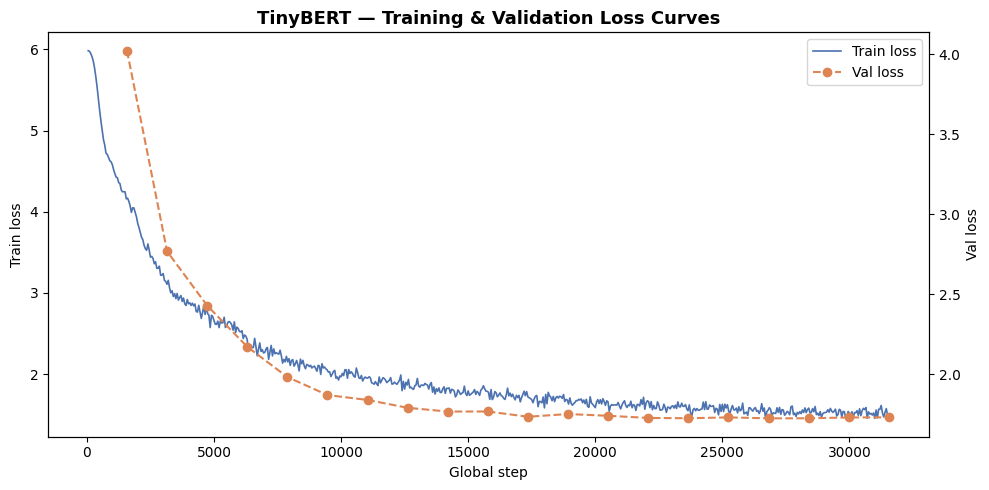

Loss curves saved → tinybert_loss_curves.png


In [26]:
tinybert_training_args = TrainingArguments(
    output_dir                  = TINYBERT_OUTPUT_DIR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,
    num_train_epochs            = NUM_EPOCHS,
    weight_decay                = WEIGHT_DECAY,
    load_best_model_at_end      = True,
    warmup_ratio                = WARMUP_RATIO,
    metric_for_best_model       = "eval_loss",
    seed                        = SEED,
    logging_steps               = 50,
    report_to                   = "none",
    fp16                        = True,
)

tinybert_trainer = Trainer(
    model         = tinybert_model,
    args          = tinybert_training_args,
    train_dataset = tb_train_dataset,
    eval_dataset  = tb_val_dataset,
    data_collator = default_data_collator,
)

print("Starting TinyBERT training...")
train_start  = time.time()
train_output = tinybert_trainer.train()
train_end    = time.time()

wall_clock_hrs = (train_end - train_start) / 3600
print(f"✅ TinyBERT training complete — wall-clock time: {wall_clock_hrs:.2f} hours")

# ── Loss Curves ──────────────────────────────────────────────
log_history  = tinybert_trainer.state.log_history
train_steps  = [e["step"]      for e in log_history if "loss"      in e]
train_losses = [e["loss"]      for e in log_history if "loss"      in e]
eval_epochs  = [e["epoch"]     for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train loss", color="#4C72B0", linewidth=1.2)
ax2 = ax.twinx()
total_train_steps = train_steps[-1] if train_steps else 1
eval_steps_approx = [int(e / NUM_EPOCHS * total_train_steps) for e in eval_epochs]
ax2.plot(eval_steps_approx, eval_losses, "o--", label="Val loss", color="#DD8452", linewidth=1.5)

ax.set_xlabel("Global step")
ax.set_ylabel("Train loss")
ax2.set_ylabel("Val loss")
ax.set_title("TinyBERT — Training & Validation Loss Curves", fontsize=13, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig("tinybert_loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Loss curves saved → tinybert_loss_curves.png")

# save model

In [27]:
tinybert_model.save_pretrained(TINYBERT_SAVE_PATH)
tinybert_tokenizer.save_pretrained(TINYBERT_SAVE_PATH)
print(f"TinyBERT model and tokenizer saved → {TINYBERT_SAVE_PATH}")

TinyBERT model and tokenizer saved → ./tinybert-squad-final


# Inference Demo


In [29]:
tb_qa_pipeline = pipeline(
    "question-answering",
    model=tinybert_model,
    tokenizer=tinybert_tokenizer,
    device=-1
)

demos = [
    {
        "question": "Who introduced BERT?",
        "context": "BERT was introduced by Devlin et al. from Google AI Language in 2019. It achieved state-of-the-art results on eleven NLP tasks."
    },
    {
        "question": "How many parameters does DistilBERT have?",
        "context": "DistilBERT, proposed by Sanh et al., reduces BERT's parameter count by 40%, resulting in approximately 66 million parameters while retaining 97% of BERT's language understanding capability."
    },
    {
        "question": "What dataset was used for evaluation?",
        "context": "The model was evaluated on SQuAD v1.1, which contains over 107,000 question-answer pairs from 536 Wikipedia articles."
    }
]

print("── TinyBERT Inference Demo ──────────────────────────────────")
for d in demos:
    ans = tb_qa_pipeline(question=d["question"], context=d["context"])
    print(f"Q: {d['question']}")
    print(f"A: {ans['answer']}  (score: {ans['score']:.4f})")
    print()

── TinyBERT Inference Demo ──────────────────────────────────
Q: Who introduced BERT?
A: Google  (score: 0.4979)

Q: How many parameters does DistilBERT have?
A: 66 million  (score: 0.1895)

Q: What dataset was used for evaluation?
A: v1  (score: 0.1092)



# CPU Latency

In [33]:
device_cpu = torch.device("cpu")
tinybert_model.to(device_cpu)
tinybert_model.eval()

sample_para = val_articles[5]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]

inputs = tinybert_tokenizer(
    question, context,
    max_length=384,
    truncation="only_second",
    return_tensors="pt"
)
inputs = {k: v.to(device_cpu) for k, v in inputs.items()}

start_time = time.time()
with torch.no_grad():
    outputs = tinybert_model(**inputs)
end_time = time.time()

tinybert_cpu_latency = (end_time - start_time) * 1000

# ── استخراج الجواب ──────────────────────────────────
start_logits = outputs.start_logits[0]
end_logits   = outputs.end_logits[0]

answer_start = start_logits.argmax().item()
answer_end   = (end_logits[answer_start:].argmax() + answer_start).item() + 1

answer_tokens = inputs["input_ids"][0][answer_start:answer_end]
answer        = tinybert_tokenizer.decode(answer_tokens.tolist(), skip_special_tokens=True)

print(f"✅ Question : {question}")
print(f"💡 Answer   : {answer}")
print(f"🚀 TinyBERT Inference time on CPU: {tinybert_cpu_latency:.2f} ms")

✅ Question : Where did Hokkien originate?
💡 Answer   : southern fujian
🚀 TinyBERT Inference time on CPU: 10.40 ms


In [31]:
device_cpu = torch.device("cpu")
tinybert_model.to(device_cpu)
tinybert_model.eval()

demos = [
    {
        "question": "Who introduced BERT?",
        "context": "BERT was introduced by Devlin et al. from Google AI Language in 2019. It achieved state-of-the-art results on eleven NLP tasks."
    },
    {
        "question": "How many parameters does DistilBERT have?",
        "context": "DistilBERT, proposed by Sanh et al., reduces BERT's parameter count by 40%, resulting in approximately 66 million parameters while retaining 97% of BERT's language understanding capability."
    },
    {
        "question": "What dataset was used for evaluation?",
        "context": "The model was evaluated on SQuAD v1.1, which contains over 107,000 question-answer pairs from 536 Wikipedia articles."
    }
]

print("── TinyBERT Inference Demo ──────────────────────────────────────")
for d in demos:
    inputs = tinybert_tokenizer(
        d["question"], d["context"],
        max_length=384,
        truncation="only_second",
        return_tensors="pt"
    )
    inputs = {k: v.to(device_cpu) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = tinybert_model(**inputs)

    answer_start  = outputs.start_logits.argmax(dim=-1).item()
    answer_end    = outputs.end_logits.argmax(dim=-1).item() + 1
    answer_tokens = inputs["input_ids"][0][answer_start:answer_end]
    answer        = tinybert_tokenizer.decode(answer_tokens.tolist(), skip_special_tokens=True)

    print(f"Q: {d['question']}")
    print(f"A: {answer}")
    print()

── TinyBERT Inference Demo ──────────────────────────────────────
Q: Who introduced BERT?
A: google

Q: How many parameters does DistilBERT have?
A: 66 million

Q: What dataset was used for evaluation?
A: v1



 #  ablation sequance length in inference

In [22]:
#  get exampeles of test data

def get_validation_examples(articles, limit=None):
    examples = []
    for article in articles:
        title = article.get("title", "")
        for para in article["paragraphs"]:
            context = para["context"]
            for qa in para["qas"]:
                if len(qa["answers"]) == 0:
                    continue
                examples.append({
                    "id":           qa["id"],
                    "title":        title,
                    "question":     qa["question"],
                    "context":      context,
                    "gold_answers": [a["text"] for a in qa["answers"]]
                })
                if limit is not None and len(examples) >= limit:
                    return examples
    return examples

# get 500 exampele
test_examples = get_validation_examples(test_articles, limit=500)
print(f"✅ Test examples loaded: {len(test_examples)}")

✅ Test examples loaded: 500


In [23]:
import string
import re
from collections import Counter
#normalize answer fr model predict and answer in data to use it in compare 
def normalize_answer(s):
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = ''.join(ch for ch in s if ch not in string.punctuation)
    s = ' '.join(s.split())
    return s
# compute exact match  1 if eqial 0 if not equal
def compute_exact(gold, prediction):
    return int(normalize_answer(gold) == normalize_answer(prediction))
# compute f1 score between prediction and data answe calc overlab words between them 
def compute_f1(gold, prediction):
    gold_tokens = normalize_answer(gold).split()
    pred_tokens = normalize_answer(prediction).split()
    common      = Counter(gold_tokens) & Counter(pred_tokens)
    num_same    = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return (2 * precision * recall) / (precision + recall)
#This function selects the best match between the model's answer and all possible correct answers, and returns the highest EM and F1
def score_prediction(gold_answers, prediction):
    em = max(compute_exact(gold, prediction) for gold in gold_answers)
    f1 = max(compute_f1(gold, prediction)    for gold in gold_answers)
    return em, f1

In [24]:

from transformers import AutoTokenizer, AutoModelForQuestionAnswering

import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForQuestionAnswering,
)
SAVE_PATH="./distilbert-squad-final"

test_examples = get_validation_examples(test_articles, limit=500)
print(f"✅ Test examples loaded: {len(test_examples)}")

#the config i work
SEQ_LENGTHS = [128, 256, 384]
STRIDE      = 64
DEVICE      = torch.device("cpu")   # cpu for inference 

distilbert_tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
distilbert_model     = AutoModelForQuestionAnswering.from_pretrained(SAVE_PATH)
distilbert_model.to(DEVICE)
distilbert_model.eval()
print("✅ DistilBERT loaded on CPU for latency measurement")

# get best prediction answer from chunks
def predict_distilbert(question, context, max_seq_len):
    inputs = distilbert_tokenizer(
        question, context,
        max_length        = max_seq_len,
        truncation        = "only_second",
        stride            = STRIDE,
        return_overflowing_tokens = True,
        return_offsets_mapping    = True,
        padding           = "max_length",
        return_tensors    = "pt",
    )
#It links each token to its actual location in the original text >Token number 5 = a character from 20 to 27 in the text
    offset_mapping = inputs.pop("offset_mapping")
    inputs.pop("overflow_to_sample_mapping", None)
    #It converts all the tensors (data) to the same device that the model is running on> 
    #{
  #  "input_ids": tensor1.to(DEVICE),
 #   "attention_mask": tensor2.to(DEVICE)
#}#
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
# run for inference without calc gradient
    with torch.no_grad():
        outputs = distilbert_model(**inputs)

    # pick best span across all chunks
    best_score  = float("-inf")
    best_answer = ""

    for i in range(outputs.start_logits.shape[0]):
        #get first and end answer prop an the get this index 
        start_idx = outputs.start_logits[i].argmax().item()
        end_idx   = outputs.end_logits[i].argmax().item()

        if end_idx < start_idx:
            continue
# get the best answer by + prop of start and end logit of answer
        score = (outputs.start_logits[i][start_idx]
               + outputs.end_logits[i][end_idx]).item()

        if score > best_score:
            best_score  = score
            offsets     = offset_mapping[i].tolist()
            start_char  = offsets[start_idx][0]
            end_char    = offsets[end_idx][1]
            best_answer = context[start_char:end_char]

    return best_answer

# ── Run 3 inference passes ────────────────────────────────────
distilbert_seq_results = []

for seq_len in SEQ_LENGTHS:
    print(f"\n{'='*55}")
    print(f"  DistilBERT  |  max_seq_len = {seq_len}")
    print(f"{'='*55}")

    rows      = []
    latencies = []

    for i, ex in enumerate(test_examples):
        t0         = time.perf_counter()
        prediction = predict_distilbert(ex["question"], ex["context"], seq_len)
        t1         = time.perf_counter()

        latency_ms = (t1 - t0) * 1000
        em, f1     = score_prediction(ex["gold_answers"], prediction)

        rows.append({"em": em, "f1": f1})
        latencies.append(latency_ms)

        if (i + 1) % 100 == 0:
            print(f"  [{i+1}/{len(test_examples)}] "
                  f"avg latency so far: {sum(latencies)/len(latencies):.1f} ms")

    avg_em      = sum(r["em"] for r in rows) / len(rows) * 100
    avg_f1      = sum(r["f1"] for r in rows) / len(rows) * 100
    avg_latency = sum(latencies) / len(latencies)

    distilbert_seq_results.append({
        "Model":        "DistilBERT",
        "Seq Length":   seq_len,
        "EM (%)":       round(avg_em,      2),
        "F1 (%)":       round(avg_f1,      2),
        "Latency (ms)": round(avg_latency, 2),
    })

    print(f"\n  ✅ EM = {avg_em:.2f}%  |  "
          f"F1 = {avg_f1:.2f}%  |  "
          f"Avg Latency = {avg_latency:.2f} ms")

# ── Results table ─────────────────────────────────────────────
distilbert_seq_df = pd.DataFrame(distilbert_seq_results)

print("\n\n📊 DistilBERT — Sequence Length Ablation (Test Set)")
print("=" * 55)
print(distilbert_seq_df.to_string(index=False))

distilbert_seq_df.to_csv("distilbert_seq_ablation.csv", index=False)
print("\n✅ Saved → distilbert_seq_ablation.csv")

✅ Test examples loaded: 500
✅ DistilBERT loaded on CPU for latency measurement

  DistilBERT  |  max_seq_len = 128
  [100/500] avg latency so far: 70.2 ms
  [200/500] avg latency so far: 63.1 ms
  [300/500] avg latency so far: 59.9 ms
  [400/500] avg latency so far: 56.9 ms
  [500/500] avg latency so far: 56.4 ms

  ✅ EM = 65.40%  |  F1 = 78.32%  |  Avg Latency = 56.43 ms

  DistilBERT  |  max_seq_len = 256
  [100/500] avg latency so far: 50.1 ms
  [200/500] avg latency so far: 50.6 ms
  [300/500] avg latency so far: 50.6 ms
  [400/500] avg latency so far: 49.5 ms
  [500/500] avg latency so far: 49.9 ms

  ✅ EM = 65.60%  |  F1 = 77.82%  |  Avg Latency = 49.87 ms

  DistilBERT  |  max_seq_len = 384
  [100/500] avg latency so far: 76.6 ms
  [200/500] avg latency so far: 73.3 ms
  [300/500] avg latency so far: 72.2 ms
  [400/500] avg latency so far: 71.7 ms
  [500/500] avg latency so far: 71.3 ms

  ✅ EM = 65.60%  |  F1 = 78.11%  |  Avg Latency = 71.35 ms


📊 DistilBERT — Sequence Length 

In [25]:
# ── Sanity Check ─────────────────────────────────────
print(f"Test articles count     : {len(test_articles)}")
print(f"Test examples count     : {len(test_examples)}")

# شوف أول سؤال في الـ test
print(f"\nFirst test example:")
print(f"  Title   : {test_examples[0]['title']}")
print(f"  Question: {test_examples[0]['question']}")
print(f"  Answer  : {test_examples[0]['gold_answers']}")

# تأكد إنه مش موجود في الـ train
train_ids = set()
for article in train_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            train_ids.add(qa["id"])

test_ids = {ex["id"] for ex in test_examples}

overlap = train_ids & test_ids
print(f"\nOverlap between train and test IDs: {len(overlap)}")
print("✅ No leakage!" if len(overlap) == 0 else "❌ DATA LEAKAGE DETECTED!")

Test articles count     : 45
Test examples count     : 500

First test example:
  Title   : Tucson,_Arizona
  Question: What is the largest populated city in Arizona?
  Answer  : ['Phoenix']

Overlap between train and test IDs: 0
✅ No leakage!


In [ ]:


from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import time
import torch
import pandas as pd

TINYBERT_SAVE_PATH = "./tinybert-squad-final"
SEQ_LENGTHS        = [128, 256, 384]
STRIDE             = 64
DEVICE             = torch.device("cpu")

tinybert_tokenizer = AutoTokenizer.from_pretrained(TINYBERT_SAVE_PATH)
tinybert_model     = AutoModelForQuestionAnswering.from_pretrained(TINYBERT_SAVE_PATH)
tinybert_model.to(DEVICE)
tinybert_model.eval()
print("✅ TinyBERT loaded on CPU for latency measurement")

def predict_tinybert(question, context, max_seq_len):
    inputs = tinybert_tokenizer(
        question, context,
        max_length                = max_seq_len,
        truncation                = "only_second",
        stride                    = STRIDE,
        return_overflowing_tokens = True,
        return_offsets_mapping    = True,
        padding                   = "max_length",
        return_tensors            = "pt",
    )

    offset_mapping = inputs.pop("offset_mapping")
    inputs.pop("overflow_to_sample_mapping", None)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = tinybert_model(**inputs)

    best_score  = float("-inf")
    best_answer = ""

    for i in range(outputs.start_logits.shape[0]):
        start_idx = outputs.start_logits[i].argmax().item()
        end_idx   = outputs.end_logits[i].argmax().item()

        if end_idx < start_idx:
            continue

        score = (outputs.start_logits[i][start_idx]
               + outputs.end_logits[i][end_idx]).item()

        if score > best_score:
            best_score  = score
            offsets     = offset_mapping[i].tolist()
            start_char  = offsets[start_idx][0]
            end_char    = offsets[end_idx][1]
            best_answer = context[start_char:end_char]

    return best_answer

tinybert_seq_results = []

for seq_len in SEQ_LENGTHS:
    print(f"\n{'='*55}")
    print(f"  TinyBERT  |  max_seq_len = {seq_len}")
    print(f"{'='*55}")

    rows      = []
    latencies = []

    for i, ex in enumerate(test_examples):
        t0         = time.perf_counter()
        prediction = predict_tinybert(ex["question"], ex["context"], seq_len)
        t1         = time.perf_counter()

        latency_ms = (t1 - t0) * 1000
        em, f1     = score_prediction(ex["gold_answers"], prediction)

        rows.append({"em": em, "f1": f1})
        latencies.append(latency_ms)

        if (i + 1) % 100 == 0:
            print(f"  [{i+1}/{len(test_examples)}] "
                  f"avg latency so far: {sum(latencies)/len(latencies):.1f} ms")

    avg_em      = sum(r["em"] for r in rows) / len(rows) * 100
    avg_f1      = sum(r["f1"] for r in rows) / len(rows) * 100
    avg_latency = sum(latencies) / len(latencies)

    tinybert_seq_results.append({
        "Model":        "TinyBERT",
        "Seq Length":   seq_len,
        "EM (%)":       round(avg_em,      2),
        "F1 (%)":       round(avg_f1,      2),
        "Latency (ms)": round(avg_latency, 2),
    })

    print(f"\n  ✅ EM = {avg_em:.2f}%  |  "
          f"F1 = {avg_f1:.2f}%  |  "
          f"Avg Latency = {avg_latency:.2f} ms")

tinybert_seq_df = pd.DataFrame(tinybert_seq_results)

print("\n\n📊 TinyBERT — Sequence Length Ablation (Test Set)")
print("=" * 55)
print(tinybert_seq_df.to_string(index=False))

tinybert_seq_df.to_csv("tinybert_seq_ablation.csv", index=False)
print("\n✅ Saved → tinybert_seq_ablation.csv")

✅ TinyBERT loaded on CPU for latency measurement

  TinyBERT  |  max_seq_len = 128
  [100/500] avg latency so far: 13.4 ms
  [200/500] avg latency so far: 11.6 ms
  [300/500] avg latency so far: 11.2 ms
  [400/500] avg latency so far: 10.6 ms
  [500/500] avg latency so far: 10.8 ms

  ✅ EM = 34.20%  |  F1 = 43.77%  |  Avg Latency = 10.82 ms

  TinyBERT  |  max_seq_len = 256
  [100/500] avg latency so far: 9.6 ms
  [200/500] avg latency so far: 9.2 ms
  [300/500] avg latency so far: 9.2 ms
  [400/500] avg latency so far: 9.0 ms
  [500/500] avg latency so far: 9.0 ms

  ✅ EM = 28.00%  |  F1 = 36.97%  |  Avg Latency = 9.02 ms

  TinyBERT  |  max_seq_len = 384
  [100/500] avg latency so far: 13.3 ms
  [200/500] avg latency so far: 13.2 ms
  [300/500] avg latency so far: 12.8 ms
  [400/500] avg latency so far: 12.6 ms
  [500/500] avg latency so far: 12.5 ms

  ✅ EM = 27.40%  |  F1 = 36.03%  |  Avg Latency = 12.49 ms


📊 TinyBERT — Sequence Length Ablation (Test Set)
   Model  Seq Length  EM

In [27]:
print("TinyBERT config:")
print(f"  Model type        : {tinybert_model.config.model_type}")
print(f"  Max position emb  : {tinybert_model.config.max_position_embeddings}")
print(f"  Hidden size       : {tinybert_model.config.hidden_size}")
print(f"  Num layers        : {tinybert_model.config.num_hidden_layers}")

print("\nDistilBERT config:")
print(f"  Model type        : {distilbert_model.config.model_type}")
print(f"  Max position emb  : {distilbert_model.config.max_position_embeddings}")
print(f"  Hidden size       : {distilbert_model.config.hidden_size}")
print(f"  Num layers        : {distilbert_model.config.num_hidden_layers}")

TinyBERT config:
  Model type        : bert
  Max position emb  : 512
  Hidden size       : 312
  Num layers        : 4

DistilBERT config:
  Model type        : distilbert
  Max position emb  : 512
  Hidden size       : 768
  Num layers        : 6


# tiny bert for different stride to be ensure different betwwen two model not becase the stride difference

In [32]:


from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import time, torch, pandas as pd

TINYBERT_SAVE_PATH = "./tinybert-squad-final"
SEQ_LENGTHS        = [128, 256, 384]
DEVICE             = torch.device("cpu")

tinybert_tokenizer = AutoTokenizer.from_pretrained(TINYBERT_SAVE_PATH)
tinybert_model     = AutoModelForQuestionAnswering.from_pretrained(TINYBERT_SAVE_PATH)
tinybert_model.to(DEVICE)
tinybert_model.eval()
print("✅ TinyBERT loaded — STRIDE = max_seq_len // 2")

def predict_tinybert_v2(question, context, max_seq_len):
    stride = max_seq_len // 2      # 128→64, 256→128, 384→192

    inputs = tinybert_tokenizer(
        question, context,
        max_length                = max_seq_len,
        truncation                = "only_second",
        stride                    = stride,
        return_overflowing_tokens = True,
        return_offsets_mapping    = True,
        padding                   = "max_length",
        return_tensors            = "pt",
    )
    offset_mapping = inputs.pop("offset_mapping")
    inputs.pop("overflow_to_sample_mapping", None)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = tinybert_model(**inputs)

    best_score, best_answer = float("-inf"), ""
    for i in range(outputs.start_logits.shape[0]):
        start_idx = outputs.start_logits[i].argmax().item()
        end_idx   = outputs.end_logits[i].argmax().item()
        if end_idx < start_idx:
            continue
        score = (outputs.start_logits[i][start_idx]
               + outputs.end_logits[i][end_idx]).item()
        if score > best_score:
            best_score  = score
            offsets     = offset_mapping[i].tolist()
            best_answer = context[offsets[start_idx][0]:offsets[end_idx][1]]
    return best_answer

tinybert_v2_results = []

for seq_len in SEQ_LENGTHS:
    stride = seq_len // 2
    print(f"\n{'='*55}")
    print(f"  TinyBERT  |  max_seq_len={seq_len}  |  stride={stride}")
    print(f"{'='*55}")

    rows, latencies = [], []

    for i, ex in enumerate(test_examples):
        t0         = time.perf_counter()
        prediction = predict_tinybert_v2(ex["question"], ex["context"], seq_len)
        t1         = time.perf_counter()

        latency_ms = (t1 - t0) * 1000
        em, f1     = score_prediction(ex["gold_answers"], prediction)
        rows.append({"em": em, "f1": f1})
        latencies.append(latency_ms)

        if (i + 1) % 100 == 0:
            print(f"  [{i+1}/500] avg latency: {sum(latencies)/len(latencies):.1f} ms")

    avg_em      = sum(r["em"] for r in rows) / len(rows) * 100
    avg_f1      = sum(r["f1"] for r in rows) / len(rows) * 100
    avg_latency = sum(latencies) / len(latencies)

    tinybert_v2_results.append({
        "Seq Length": seq_len,
        "Stride":     stride,
        "EM (%)":     round(avg_em,      2),
        "F1 (%)":     round(avg_f1,      2),
        "Latency ms": round(avg_latency, 2),
    })
    print(f"\n  ✅ EM={avg_em:.2f}%  F1={avg_f1:.2f}%  Latency={avg_latency:.2f}ms")

old_em = [34.20, 28.00, 27.40]
old_f1 = [43.77, 36.97, 36.03]

df_compare = pd.DataFrame({
    "Seq Length":        SEQ_LENGTHS,
    "Stride (old=64)":   [64, 64, 64],
    "Stride (new)":      [r["Stride"] for r in tinybert_v2_results],
    "EM old (%)":        old_em,
    "EM new (%)":        [r["EM (%)"] for r in tinybert_v2_results],
    "F1 old (%)":        old_f1,
    "F1 new (%)":        [r["F1 (%)"] for r in tinybert_v2_results],
    "Latency ms":        [r["Latency ms"] for r in tinybert_v2_results],
})

print("\n\n📊 TinyBERT — Stride Comparison (Test Set)")
print("=" * 70)
print(df_compare.to_string(index=False))

df_compare.to_csv("tinybert_stride_comparison.csv", index=False)
print("\n✅ Saved → tinybert_stride_comparison.csv")

✅ TinyBERT loaded — STRIDE = max_seq_len // 2

  TinyBERT  |  max_seq_len=128  |  stride=64
  [100/500] avg latency: 10.0 ms
  [200/500] avg latency: 10.2 ms
  [300/500] avg latency: 10.2 ms
  [400/500] avg latency: 9.7 ms
  [500/500] avg latency: 10.0 ms

  ✅ EM=34.20%  F1=43.77%  Latency=10.03ms

  TinyBERT  |  max_seq_len=256  |  stride=128
  [100/500] avg latency: 10.6 ms
  [200/500] avg latency: 9.8 ms
  [300/500] avg latency: 9.6 ms
  [400/500] avg latency: 9.3 ms
  [500/500] avg latency: 9.2 ms

  ✅ EM=27.80%  F1=36.96%  Latency=9.21ms

  TinyBERT  |  max_seq_len=384  |  stride=192
  [100/500] avg latency: 13.4 ms
  [200/500] avg latency: 12.9 ms
  [300/500] avg latency: 12.6 ms
  [400/500] avg latency: 12.5 ms
  [500/500] avg latency: 12.5 ms

  ✅ EM=27.40%  F1=36.02%  Latency=12.46ms


📊 TinyBERT — Stride Comparison (Test Set)
 Seq Length  Stride (old=64)  Stride (new)  EM old (%)  EM new (%)  F1 old (%)  F1 new (%)  Latency ms
        128               64            64       


📊 TABLE 1: Exact Match (%) — 2×3 Comparison
     Model  128 tokens  256 tokens  384 tokens
DistilBERT        65.4        65.6        65.6
  TinyBERT        34.2        27.8        27.4

📊 TABLE 2: F1 Score (%) — 2×3 Comparison
     Model  128 tokens  256 tokens  384 tokens
DistilBERT       78.32       77.82       78.11
  TinyBERT       43.77       36.96       36.02

📊 TABLE 3: Latency (ms) — 2×3 Comparison
     Model  128 tokens  256 tokens  384 tokens
DistilBERT       56.43       49.87       71.35
  TinyBERT       10.03        9.21       12.46



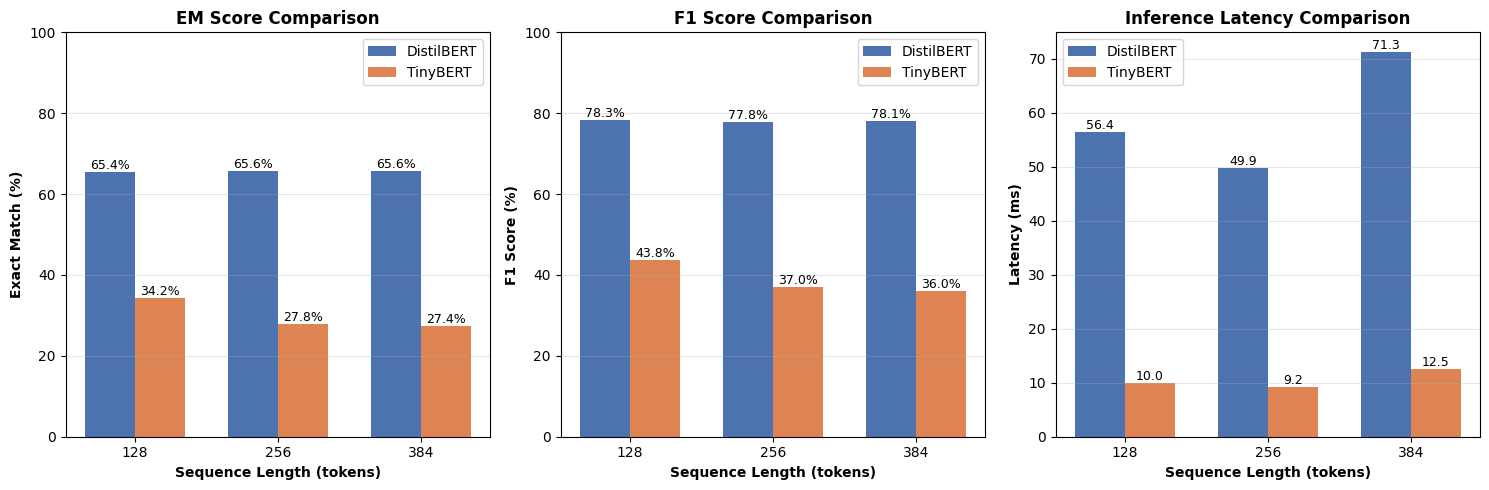

✅ Saved → distilbert_vs_tinybert_comparison.png


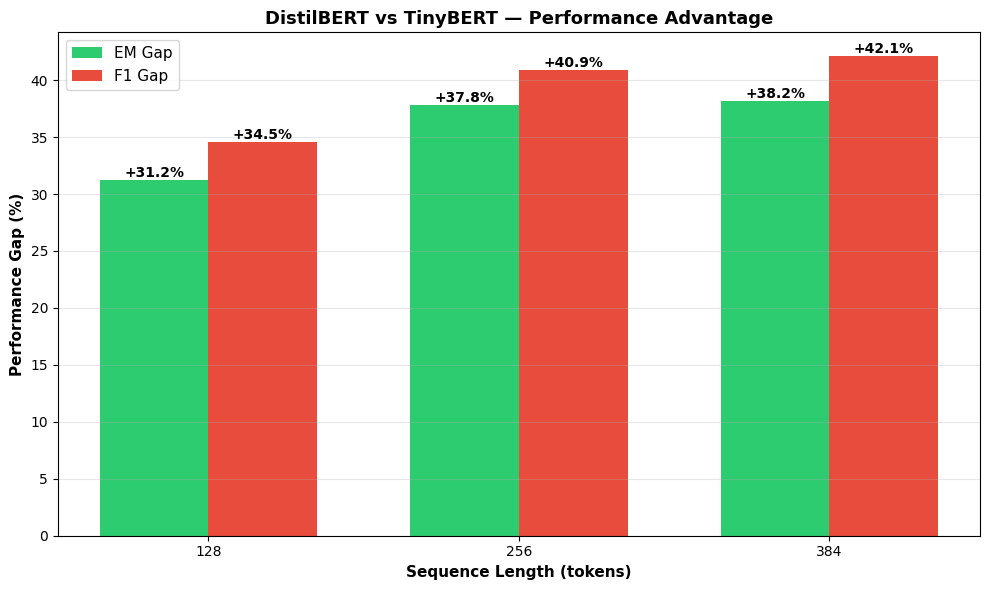

✅ Saved → performance_gap_comparison.png

📈 SUMMARY STATISTICS

Exact Match (EM):
  DistilBERT avg  : 65.53%
  TinyBERT avg    : 29.80%
  DistilBERT advantage : +35.73%

F1 Score:
  DistilBERT avg  : 78.08%
  TinyBERT avg    : 38.92%
  DistilBERT advantage : +39.17%

Latency (ms):
  DistilBERT avg  : 59.22 ms
  TinyBERT avg    : 10.57 ms
  TinyBERT speedup: 5.6x faster



In [33]:
# 2×3 Comparison Table: DistilBERT vs TinyBERT

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Data ─────────────────────────────────────────────────────
distilbert_results = {
    128: {"EM": 65.4, "F1": 78.32, "Latency": 56.43},
    256: {"EM": 65.6, "F1": 77.82, "Latency": 49.87},
    384: {"EM": 65.6, "F1": 78.11, "Latency": 71.35},
}

tinybert_results = {
    128: {"EM": 34.2, "F1": 43.77, "Latency": 10.03},
    256: {"EM": 27.8, "F1": 36.96, "Latency": 9.21},
    384: {"EM": 27.4, "F1": 36.02, "Latency": 12.46},
}

# ── Table 1: EM% ─────────────────────────────────────────────
print("\n📊 TABLE 1: Exact Match (%) — 2×3 Comparison")
print("=" * 60)
df_em = pd.DataFrame({
    "Model": ["DistilBERT", "TinyBERT"],
    "128 tokens": [distilbert_results[128]["EM"], tinybert_results[128]["EM"]],
    "256 tokens": [distilbert_results[256]["EM"], tinybert_results[256]["EM"]],
    "384 tokens": [distilbert_results[384]["EM"], tinybert_results[384]["EM"]],
})
print(df_em.to_string(index=False))
print()

# ── Table 2: F1% ─────────────────────────────────────────────
print("📊 TABLE 2: F1 Score (%) — 2×3 Comparison")
print("=" * 60)
df_f1 = pd.DataFrame({
    "Model": ["DistilBERT", "TinyBERT"],
    "128 tokens": [distilbert_results[128]["F1"], tinybert_results[128]["F1"]],
    "256 tokens": [distilbert_results[256]["F1"], tinybert_results[256]["F1"]],
    "384 tokens": [distilbert_results[384]["F1"], tinybert_results[384]["F1"]],
})
print(df_f1.to_string(index=False))
print()

# ── Table 3: Latency (ms) ────────────────────────────────────
print("📊 TABLE 3: Latency (ms) — 2×3 Comparison")
print("=" * 60)
df_latency = pd.DataFrame({
    "Model": ["DistilBERT", "TinyBERT"],
    "128 tokens": [distilbert_results[128]["Latency"], tinybert_results[128]["Latency"]],
    "256 tokens": [distilbert_results[256]["Latency"], tinybert_results[256]["Latency"]],
    "384 tokens": [distilbert_results[384]["Latency"], tinybert_results[384]["Latency"]],
})
print(df_latency.to_string(index=False))
print()

# ── Save tables ──────────────────────────────────────────────
df_em.to_csv("comparison_em.csv", index=False)
df_f1.to_csv("comparison_f1.csv", index=False)
df_latency.to_csv("comparison_latency.csv", index=False)

# ============================================================
# CHART 1: EM% Comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

seq_lengths = [128, 256, 384]
models = ["DistilBERT", "TinyBERT"]
colors = ["#4C72B0", "#DD8452"]

# ── Chart 1a: EM% ───────────────────────────────────────────
ax = axes[0]
x = range(len(seq_lengths))
width = 0.35
distilbert_em = [distilbert_results[s]["EM"] for s in seq_lengths]
tinybert_em = [tinybert_results[s]["EM"] for s in seq_lengths]

bars1 = ax.bar([i - width/2 for i in x], distilbert_em, width, label="DistilBERT", color=colors[0])
bars2 = ax.bar([i + width/2 for i in x], tinybert_em, width, label="TinyBERT", color=colors[1])

ax.set_xlabel("Sequence Length (tokens)", fontweight="bold")
ax.set_ylabel("Exact Match (%)", fontweight="bold")
ax.set_title("EM Score Comparison", fontweight="bold", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(seq_lengths)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 100)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# ── Chart 1b: F1% ───────────────────────────────────────────
ax = axes[1]
distilbert_f1 = [distilbert_results[s]["F1"] for s in seq_lengths]
tinybert_f1 = [tinybert_results[s]["F1"] for s in seq_lengths]

bars1 = ax.bar([i - width/2 for i in x], distilbert_f1, width, label="DistilBERT", color=colors[0])
bars2 = ax.bar([i + width/2 for i in x], tinybert_f1, width, label="TinyBERT", color=colors[1])

ax.set_xlabel("Sequence Length (tokens)", fontweight="bold")
ax.set_ylabel("F1 Score (%)", fontweight="bold")
ax.set_title("F1 Score Comparison", fontweight="bold", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(seq_lengths)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 100)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# ── Chart 1c: Latency (ms) ──────────────────────────────────
ax = axes[2]
distilbert_lat = [distilbert_results[s]["Latency"] for s in seq_lengths]
tinybert_lat = [tinybert_results[s]["Latency"] for s in seq_lengths]

bars1 = ax.bar([i - width/2 for i in x], distilbert_lat, width, label="DistilBERT", color=colors[0])
bars2 = ax.bar([i + width/2 for i in x], tinybert_lat, width, label="TinyBERT", color=colors[1])

ax.set_xlabel("Sequence Length (tokens)", fontweight="bold")
ax.set_ylabel("Latency (ms)", fontweight="bold")
ax.set_title("Inference Latency Comparison", fontweight="bold", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(seq_lengths)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("distilbert_vs_tinybert_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved → distilbert_vs_tinybert_comparison.png")

# ============================================================
# CHART 2: Performance Gap (الفروقات)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

gap_em = [distilbert_results[s]["EM"] - tinybert_results[s]["EM"] for s in seq_lengths]
gap_f1 = [distilbert_results[s]["F1"] - tinybert_results[s]["F1"] for s in seq_lengths]

x = range(len(seq_lengths))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], gap_em, width, label="EM Gap", color="#2ecc71")
bars2 = ax.bar([i + width/2 for i in x], gap_f1, width, label="F1 Gap", color="#e74c3c")

ax.set_xlabel("Sequence Length (tokens)", fontweight="bold", fontsize=11)
ax.set_ylabel("Performance Gap (%)", fontweight="bold", fontsize=11)
ax.set_title("DistilBERT vs TinyBERT — Performance Advantage", fontweight="bold", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(seq_lengths)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'+{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("performance_gap_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved → performance_gap_comparison.png")

# ============================================================
# Summary Statistics
# ============================================================
print("\n" + "="*60)
print("📈 SUMMARY STATISTICS")
print("="*60)

avg_distilbert_em = sum([distilbert_results[s]["EM"] for s in seq_lengths]) / len(seq_lengths)
avg_tinybert_em = sum([tinybert_results[s]["EM"] for s in seq_lengths]) / len(seq_lengths)
avg_gap = avg_distilbert_em - avg_tinybert_em

print(f"\nExact Match (EM):")
print(f"  DistilBERT avg  : {avg_distilbert_em:.2f}%")
print(f"  TinyBERT avg    : {avg_tinybert_em:.2f}%")
print(f"  DistilBERT advantage : +{avg_gap:.2f}%")

avg_distilbert_f1 = sum([distilbert_results[s]["F1"] for s in seq_lengths]) / len(seq_lengths)
avg_tinybert_f1 = sum([tinybert_results[s]["F1"] for s in seq_lengths]) / len(seq_lengths)
avg_f1_gap = avg_distilbert_f1 - avg_tinybert_f1

print(f"\nF1 Score:")
print(f"  DistilBERT avg  : {avg_distilbert_f1:.2f}%")
print(f"  TinyBERT avg    : {avg_tinybert_f1:.2f}%")
print(f"  DistilBERT advantage : +{avg_f1_gap:.2f}%")

avg_distilbert_lat = sum([distilbert_results[s]["Latency"] for s in seq_lengths]) / len(seq_lengths)
avg_tinybert_lat = sum([tinybert_results[s]["Latency"] for s in seq_lengths]) / len(seq_lengths)
latency_ratio = avg_distilbert_lat / avg_tinybert_lat

print(f"\nLatency (ms):")
print(f"  DistilBERT avg  : {avg_distilbert_lat:.2f} ms")
print(f"  TinyBERT avg    : {avg_tinybert_lat:.2f} ms")
print(f"  TinyBERT speedup: {latency_ratio:.1f}x faster")

print("\n" + "="*60)

The results show a trade-off between speed and accuracy. DistilBERT performs better in accuracy (EM and F1), meaning it understands the context and finds answers more correctly. On the other hand, TinyBERT is much faster (about 5.6× speedup), but its accuracy is lower.

TinyBERT showed performance degradation at longer sequence lengths (EM: 34.2% → 27.4%), consistent with its limited model capacity (14M parameters, 4 layers) compared to DistilBERT (66M parameters, 6 layers) which remained stable across all lengths.



Changing stride had almost no effect on TinyBERT. The performance drop comes from its small model size, not from tokenization. TinyBERT struggles with long contexts, while DistilBERT stays stable.

# ----------------------------------

In [1]:
#---